# 📊 Classification des emotions a partir d'un texte :

Le but de ce notebook est d'appliquer tout ce qu'on a vu dans toutes les secances des NLP (cours et TP) sur un corpus pour la classification des emotions en (***joy*** - ***sadness*** - ***anger*** - ***fear*** )

 📓 On va voir dan se notebook :

1.   Chargement de dataset
2.   exploration du dataset
3.   traitement du dataset(Nettoyage)
4.   Tokenization
5.   Vectorisation avec TF-IDF
7.   Implementation du Logistic Regression pour la classification
8.   Entrainement et test du modele
9.   Sauvgarde du modele



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib


In [3]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Chargement de dataset

In [26]:
emotion_csv='/content/drive/MyDrive/Salma_EL_FORKANI/Data/combined_emotion.csv'
df=pd.read_csv(emotion_csv)


# Exploration du dataset

In [27]:
print("Les 5 premiers lignes de emotion csv")
df.head()

Les 5 premiers lignes de emotion csv


,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sad
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sad
4,i am a kindergarten teacher and i am thoroughl...,fear


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422746 entries, 0 to 422745
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   sentence  422746 non-null  object
 1   emotion   422746 non-null  object
dtypes: object(2)
memory usage: 6.5+ MB


In [29]:
df.shape

(422746, 2)

In [30]:
print("Les colonnes de emotion csv")
df.columns

Les colonnes de emotion csv


Index(['sentence', 'emotion'], dtype='object')

In [31]:
df['emotion'].unique()
df['emotion'].value_counts()

,count
emotion,
joy,143067
sad,121187
anger,59317
fear,49649
love,34554
suprise,14972


<Axes: >

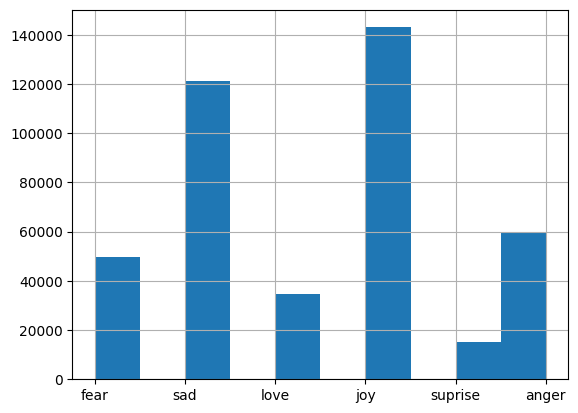

In [32]:
df['emotion'].hist()

In [33]:
df = df[~df["emotion"].isin(["suprise", "love"])]

In [34]:
df = df.reset_index(drop=True)

In [35]:
df['emotion'].unique()
df['emotion'].value_counts()

,count
emotion,
joy,143067
sad,121187
anger,59317
fear,49649


In [37]:
df.isnull().sum()

,0
sentence,0
emotion,0


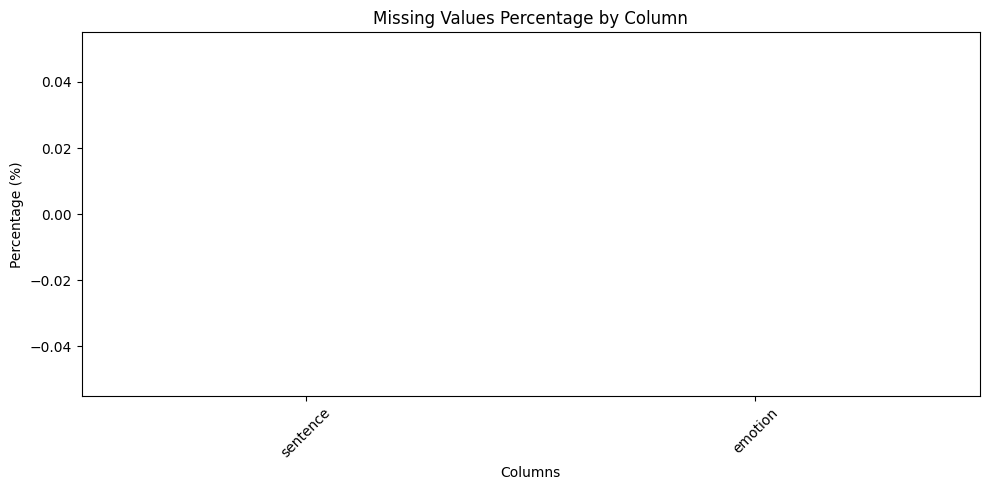

In [38]:
# Visualiser les valeurs manquantes
plt.figure(figsize=(10, 5))
missing_pct = (df.isnull().sum() / len(df) * 100)
colors = ['green' if x == 0 else 'orange' for x in missing_pct]
missing_pct.plot(kind='bar', color=colors)
plt.title('Missing Values Percentage by Column')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 6553


In [40]:
# Nombre de doublons dans la colonne 'sentence'
duplicate_sentences = df["sentence"].duplicated().sum()
print(f"Number of duplicated sentences: {duplicate_sentences}")


Number of duplicated sentences: 13606


In [41]:
# Afficher les phrases dupliquées
duplicated_rows = df[df["sentence"].duplicated(keep=False)]  # keep=False -> montre toutes les copies
duplicated_rows.sort_values("sentence", inplace=True)
duplicated_rows.head(10)


/tmp/ipython-input-1207262204.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplicated_rows.sort_values("sentence", inplace=True)


,sentence,emotion
369253,a boyfriend with whom i split up with came ove...,anger
218445,a boyfriend with whom i split up with came ove...,anger
275260,a certain friend tried to push me off a seat i...,anger
370636,a certain friend tried to push me off a seat i...,anger
314281,a few monthe ago,anger
367903,a few monthe ago,anger
252841,a gigantic spider climbed over my face and wha...,anger
371918,a gigantic spider climbed over my face and wha...,anger
279149,a girl entered in the division where i work an...,anger
367551,a girl entered in the division where i work an...,anger


In [42]:
df = df.drop_duplicates()
print("nouvelle shape apres suppression:", df.shape)


nouvelle shape apres suppression: (366667, 2)


In [43]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


# Traitement du dataset(Nettoyage)

In [44]:
stop = set(stopwords.words('english'))


def create_corpus(emotion_label):
    """
    Create a corpus of words for a specific emotion.

    Parameters:
    -----------
    emotion_label : str
        Emotion class (joy, sad, anger, fear)

    Returns:
    --------
    list : List of words in the corpus
    """
    corpus = []
    subset = df[df["emotion"] == emotion_label]

    for sentence in subset["sentence"]:
        for word in sentence.split():
            word = word.lower()
            if word not in stop and word.isalpha():
                corpus.append(word)

    return corpus

In [45]:
emotions = ["joy", "sad", "anger", "fear"]

corpora = {}

for emo in emotions:
    corpora[emo] = create_corpus(emo)
    print(f"{emo.upper():<10} → {len(corpora[emo])} words")


JOY        → 1339938 words
SAD        → 1096091 words
ANGER      → 529898 words
FEAR       → 439644 words


In [46]:
print("=" * 60)
print("Les mots les plus frequents par emotion")
print("=" * 60)

for emo in emotions:
    print(f"\n Top 5 mots pour chaque emotion: {emo.upper()}")
    common_words = Counter(corpora[emo]).most_common(5)
    for word, count in common_words:
        print(f"  {word}: {count}")


Les mots les plus frequents par emotion

 Top 5 mots pour chaque emotion: JOY
  feel: 102481
  feeling: 40881
  like: 25216
  im: 20402
  really: 8502

 Top 5 mots pour chaque emotion: SAD
  feel: 84018
  feeling: 40816
  like: 22134
  im: 17601
  really: 7528

 Top 5 mots pour chaque emotion: ANGER
  feel: 37653
  feeling: 19219
  like: 10355
  im: 9284
  really: 3771

 Top 5 mots pour chaque emotion: FEAR
  feel: 30873
  feeling: 17664
  im: 7540
  like: 6251
  little: 3516


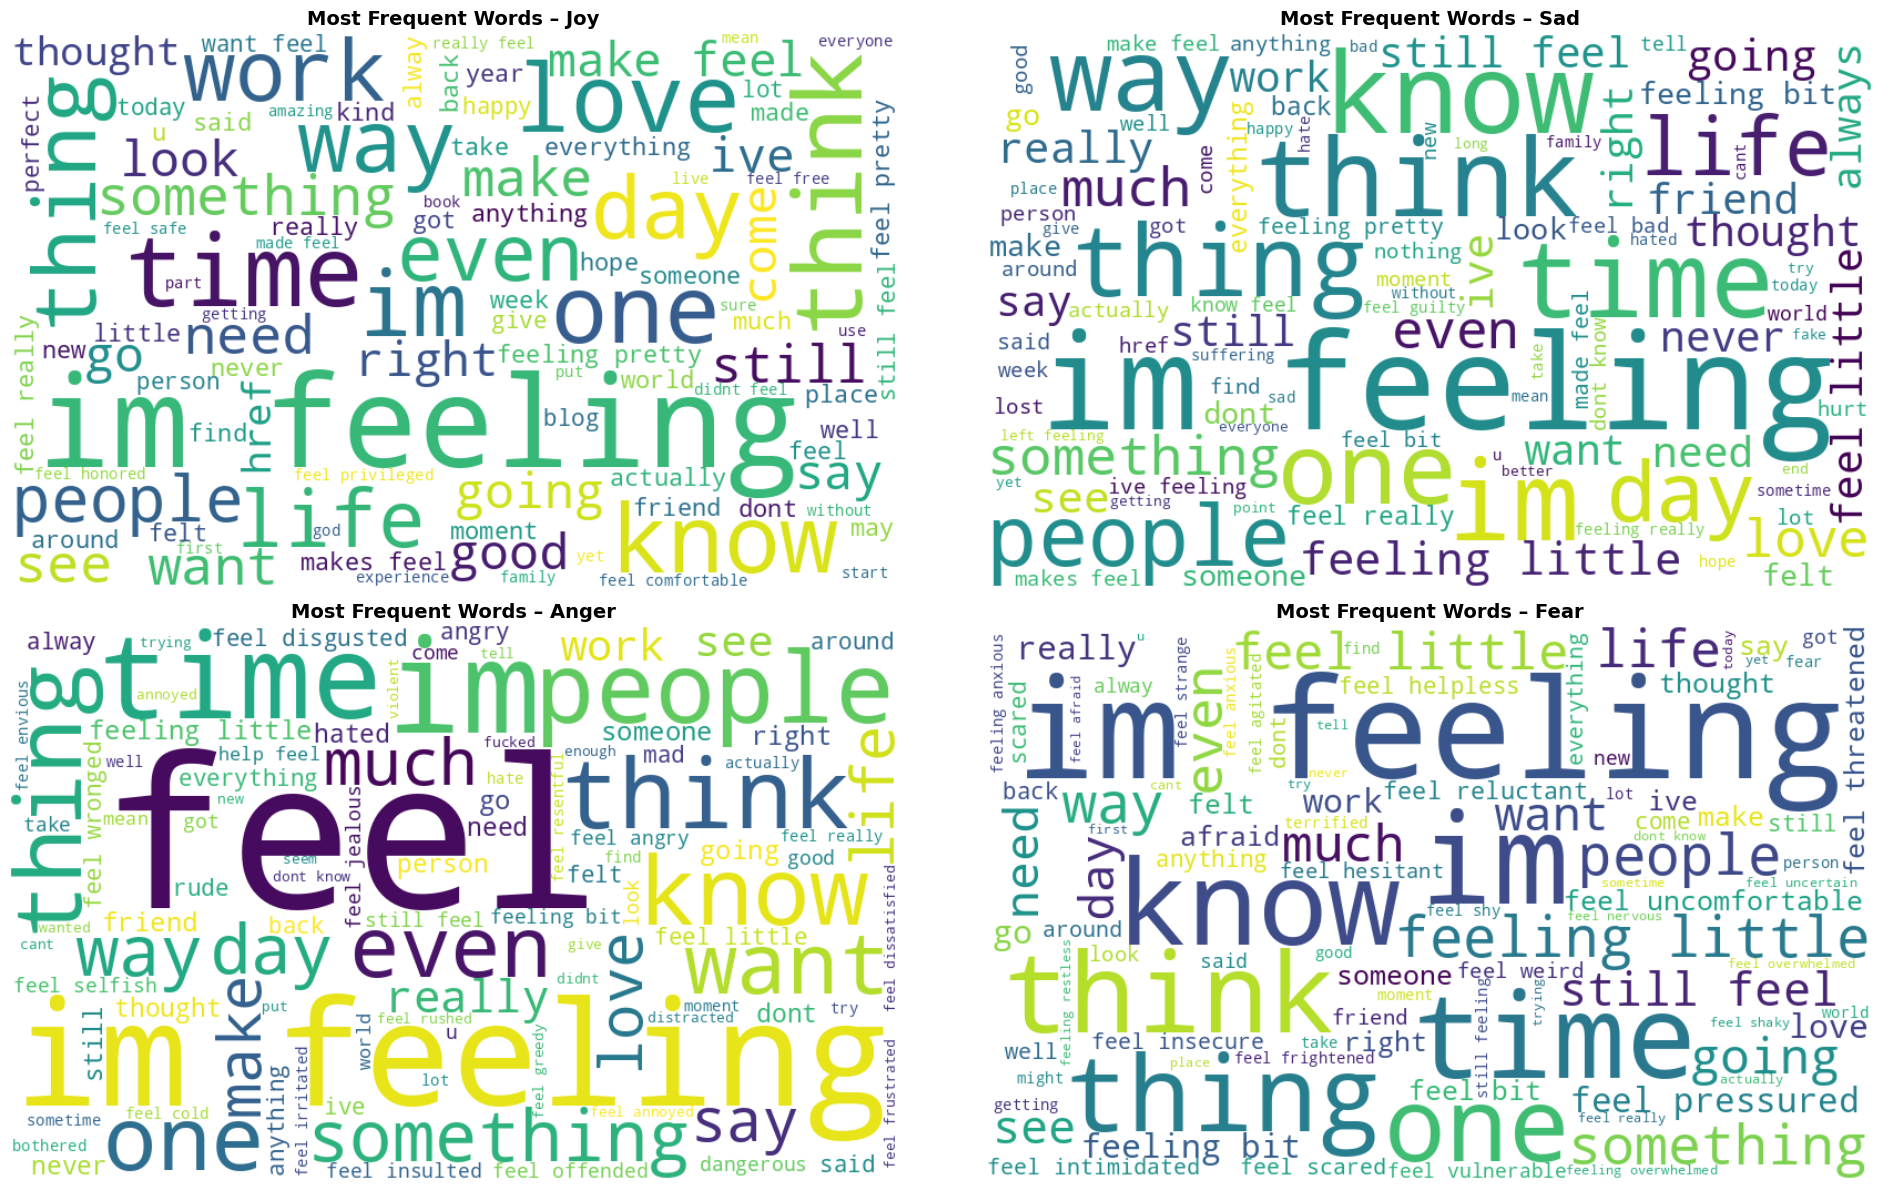

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for idx, emo in enumerate(emotions):
    text = " ".join(corpora[emo])
    wc = WordCloud(
        background_color="white",
        width=800,
        height=500,
        max_words=100
    ).generate(text)

    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Most Frequent Words – {emo.capitalize()}",
                        fontsize=14, fontweight="bold")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


# Tokenization

In [49]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Nettoyage
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenisation avec regex
    tokens = re.findall(r'\b\w+\b', text)

    # Suppression des stopwords + lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return tokens



In [50]:
df["tokens"] = df["sentence"].apply(preprocess)
df.head()

,sentence,emotion,tokens
0,i just feel really helpless and heavy hearted,fear,"[feel, really, helpless, heavy, hearted]"
1,ive enjoyed being able to slouch about relax a...,sad,"[ive, enjoyed, able, slouch, relax, unwind, fr..."
2,i gave up my internship with the dmrg and am f...,fear,"[gave, internship, dmrg, feeling, distraught]"
3,i dont know i feel so lost,sad,"[dont, know, feel, lost]"
4,i am a kindergarten teacher and i am thoroughl...,fear,"[kindergarten, teacher, thoroughly, weary, job..."


In [51]:
# Créer le corpus global
all_tokens = [token for tokens in df["tokens"] for token in tokens]
token_counts = Counter(all_tokens)

# Hapax = token qui apparaît une seule fois
hapax = {token for token, count in token_counts.items() if count == 1}

# Supprimer les hapax
df["tokens"] = df["tokens"].apply(lambda tokens: [t for t in tokens if t not in hapax])



Top 10 tokens for FEAR:
  feel: 31882
  feeling: 18403
  im: 7540
  like: 6278
  little: 3516
  know: 3124
  time: 2978
  really: 2800
  bit: 2442
  still: 2390


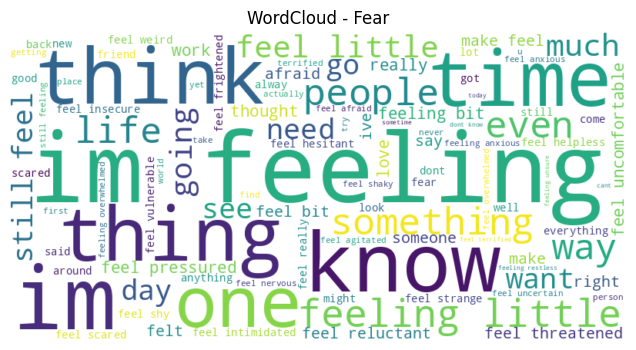


Top 10 tokens for SAD:
  feel: 86279
  feeling: 43409
  like: 22206
  im: 17601
  time: 7615
  really: 7528
  know: 7357
  get: 5721
  little: 5720
  day: 5391


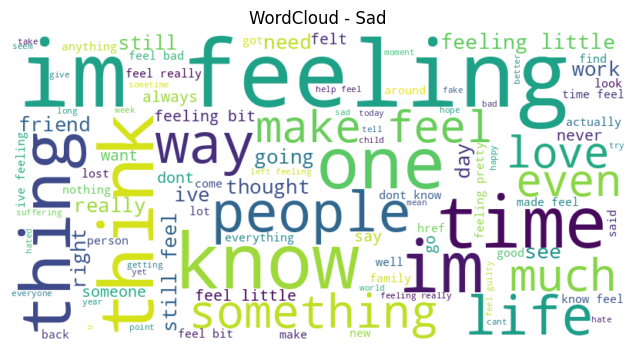


Top 10 tokens for JOY:
  feel: 105396
  feeling: 43492
  like: 25334
  im: 20402
  really: 8502
  time: 8342
  make: 7723
  know: 7361
  get: 6824
  day: 6332


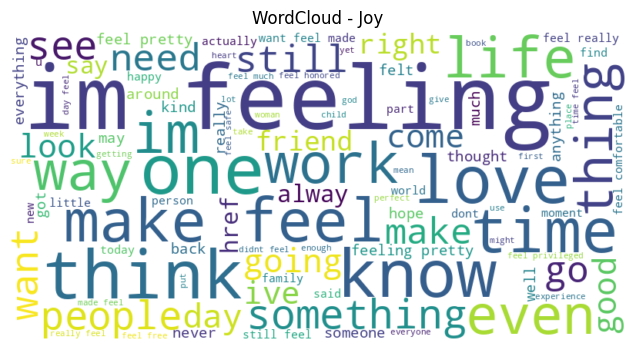


Top 10 tokens for ANGER:
  feel: 38727
  feeling: 20427
  like: 10396
  im: 9284
  really: 3771
  time: 3571
  get: 3563
  know: 3494
  people: 3183
  little: 2826


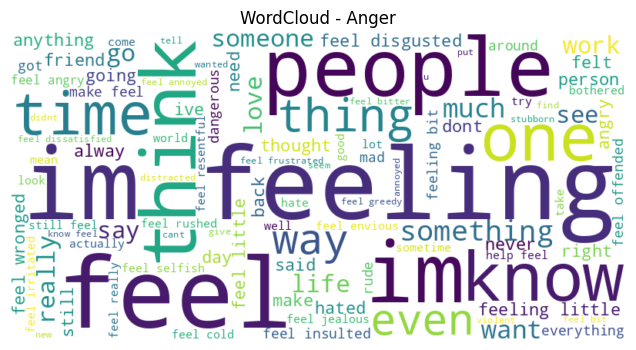

In [52]:
emotions = df["emotion"].unique()

for emo in emotions:
    emo_tokens = [token for tokens in df[df["emotion"]==emo]["tokens"] for token in tokens]
    most_common = Counter(emo_tokens).most_common(10)
    print(f"\nTop 10 tokens for {emo.upper()}:")
    for token, count in most_common:
        print(f"  {token}: {count}")


    wc = WordCloud(background_color="white", width=800, height=400, max_words=100).generate(" ".join(emo_tokens))

    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {emo.capitalize()}")
    plt.show()


In [53]:
df["text_clean"] = df["tokens"].apply(lambda tokens: " ".join(tokens))


In [54]:
df.head()

,sentence,emotion,tokens,text_clean
0,i just feel really helpless and heavy hearted,fear,"[feel, really, helpless, heavy, hearted]",feel really helpless heavy hearted
1,ive enjoyed being able to slouch about relax a...,sad,"[ive, enjoyed, able, slouch, relax, unwind, fr...",ive enjoyed able slouch relax unwind frankly n...
2,i gave up my internship with the dmrg and am f...,fear,"[gave, internship, feeling, distraught]",gave internship feeling distraught
3,i dont know i feel so lost,sad,"[dont, know, feel, lost]",dont know feel lost
4,i am a kindergarten teacher and i am thoroughl...,fear,"[kindergarten, teacher, thoroughly, weary, job...",kindergarten teacher thoroughly weary job take...


# Pipeline de vectorisation avec TF-IDF et implementation du Logistic Regression pour la classification

In [55]:
X = df["text_clean"]
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [56]:
model_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("classifier", LogisticRegression(max_iter=1000, multi_class="auto"))
])


# Entrainement et test du modele

In [57]:
model_pipeline.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(max_iter=1000, multi_class='auto'))])

In [58]:
y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.9550822265252135

Classification Report:

              precision    recall  f1-score   support

       anger       0.92      0.91      0.92     11447
        fear       0.92      0.91      0.92      9533
         joy       0.98      0.99      0.98     28156
         sad       0.96      0.96      0.96     24198

    accuracy                           0.96     73334
   macro avg       0.95      0.94      0.94     73334
weighted avg       0.95      0.96      0.95     73334



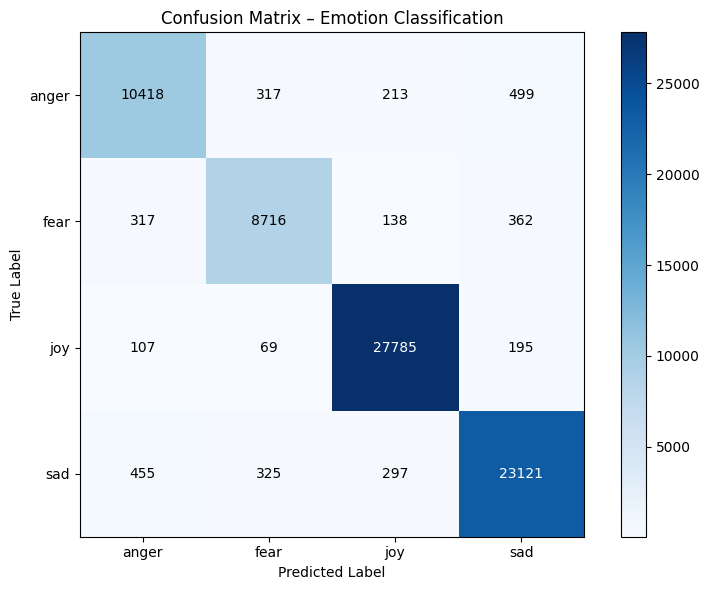

In [59]:
labels = model_pipeline.classes_
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Emotion Classification")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

# Sauvgarde du modele

In [60]:
import os
os.makedirs("model", exist_ok=True)
joblib.dump(model_pipeline, "/content/drive/MyDrive/Salma_EL_FORKANI/model/emotion_detector.pkl")

['/content/drive/MyDrive/Salma_EL_FORKANI/model/emotion_detector.pkl']